"multi-label classification is all about dependence, and a successful multi-label approach is one that exploits information about label dependencies."

This notebook provides a theoretical introduction to the topic and an exploration of the data.

#Definition

Diferently from traditional multiclass problems, in which the model's forced to choose between one of a set of existing options (labels are mutually exclusive), in multilabel classification, a same input can be correctly associated with various categories. Each label is treated as an independent (or so, even though, when there's a lot of labels, some as often correlated) binary decision.

#Loss

Math-wise, the difference lies mainly on the loss function to be optimized during training. Multiclass models most commonly apply softmax activations to the outputs and then computes cross entropy loss. On the other hand, in multilabel classification we apply sigmoid activations separately to each, calculates binary cross entropy loss for each, also separately, and then combine all, in what's called binary cross entropy loss with logits. 

#Approach

The most common way of dealing with multilabel problems is to face it differently as multiclass ones. Say that you have X possible labels, you then build X independent binary models to choose on each label. As we will later see, this is not possible in this case, since we have over 150 labels: that's too much computation needed for a single evaluation. Another possible (but even more unfeasible) approach is to gather all possible label combinations and treat each as a class, with a single model choosing between all. This results in an enormous set of possible outputs, which is definitely not practical to deal with. (those are the known "one-vs-one", "one-vs-all", "all-vs-all" etc problems)

#Evaluation

In multiclass problems, evaluation metrics usually derive from the confusion matrix, whereas in multilabel tasks, the co-occurrence matrix is usually more suitable. Since it is mostly informative, rather than evaluative, it is possible, for example, to compare the validation set's matrix with the training set one: significant differences can indicate whether the model's learning is on the right path. Other success metrics (which can be ranking-based, label-based, or example-based) can also be used: we can look at the hamming loss (% of incorrect labels), F1-score, One-Error, Coverage Error,  and Jaccard index. Those are important once optimization under one metric can decrease performance under another metric.

#Challenges

1) labels are often related, specially when there's a big set of labels. Taking into account this correlation between them could be benefitial to performance, but is quite tricky.
2) inbalanced labels, as in most tasks. there's several strategies to deal with that: from sampling (over for minority/under for majority), to weighted loss functions and metrics.
3) the more labels we have, the more combinations are possible between them, many of which might be rare. some techniques of hierarchical classification may be useful here.
4) label's importance may be different, and understanding which to prioritize is quite nos as obvious as with multiclass.

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_parquet("val.parquet")

In [8]:
df.head(3)

,id_exemplo,texto,labels,Processo,Origem,Assuntos,Classe_abrev,Data_Autuacao,Data_Decisao,Data_Publicacao,Relator_atual,Partes,Decisao,Legislacao,Observacao_01,Observacao_02
0,val_000000,DECISÃO: - Vistos. O acórdão proferido pela 1ª...,"[DIREITO TRIBUTÁRIO, IMPOSTOS, IRPJ/IMPOSTO DE...",RE-306188,PR,1 - DIREITO TRIBUTÁRIO | IMPOSTOS | IRPJ/IMPOS...,RE,2001-04-05,13/05/2003,04/06/2003,MIN. RICARDO LEWANDOWSKI,RECURSO EXTRAORDINÁRIO N. 306.188-7\r\r\nPROCE...,DECISÃO: - Vistos. O acórdão proferido pela 1ª...,,,
1,val_000001,(PG/STF 112525/03) DECISÃO: O Senhor President...,[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE D...,MS-24572,DF,1 - DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS D...,MS,2003-06-20,10/09/2003,16/09/2003,MIN. CELSO DE MELLO,MANDADO DE SEGURANÇA N. 24.572-7\r\r\nPROCED.:...,(PG/STF 112525/03) DECISÃO: O Senhor President...,LEG-FED CF ANO-1988\r\r\n ART...,,WBS
2,val_000002,DECISÃO UNIVERSIDADE – SISTEMA DE COTAS – RECU...,[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE D...,AC-2452,SC,1 - DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS D...,AC,2009-09-23,03/10/2009,16/10/2009,MIN. MARCO AURÉLIO,AUTOR(A/S)(ES) : DANIELLE FLOR DA COSTA\r...,DECISÃO UNIVERSIDADE – SISTEMA DE COTAS – RECU...,LEG-FED CF ANO-1988\r\r\n ART...,,CMA


In [9]:
df.columns

Index(['id_exemplo', 'texto', 'labels', 'Processo', 'Origem', 'Assuntos',
       'Classe_abrev', 'Data_Autuacao', 'Data_Decisao', 'Data_Publicacao',
       'Relator_atual', 'Partes', 'Decisao', 'Legislacao', 'Observacao_01',
       'Observacao_02'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50542 entries, 0 to 50541
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_exemplo       50542 non-null  object
 1   texto            50542 non-null  object
 2   labels           50542 non-null  object
 3   Processo         50542 non-null  object
 4   Origem           50542 non-null  object
 5   Assuntos         50542 non-null  object
 6   Classe_abrev     50542 non-null  object
 7   Data_Autuacao    50542 non-null  object
 8   Data_Decisao     50542 non-null  object
 9   Data_Publicacao  50540 non-null  object
 10  Relator_atual    50538 non-null  object
 11  Partes           50542 non-null  object
 12  Decisao          50542 non-null  object
 13  Legislacao       50542 non-null  object
 14  Observacao_01    50542 non-null  object
 15  Observacao_02    50542 non-null  object
 16  labels_list      50542 non-null  object
 17  num_labels       50542 non-null

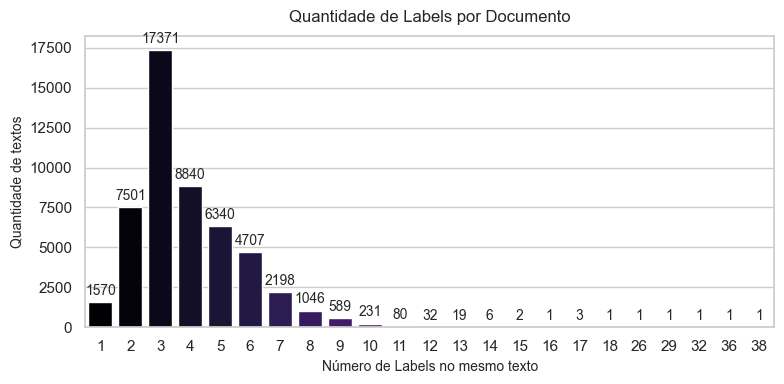

In [16]:
df["num_labels"] = df["labels_list"].apply(len)
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")
ax_dist = sns.countplot(data=df, x="num_labels", hue="num_labels", palette="magma", legend=False)

for container in ax_dist.containers:
    ax_dist.bar_label(container, padding=3, fontsize=10)

plt.title("Quantidade de Labels por Documento", fontsize=12, pad=10)
plt.xlabel("Número de Labels no mesmo texto", fontsize=10)
plt.ylabel("Quantidade de textos", fontsize=10)
plt.tight_layout()
plt.show()

Assim como na maioria dos problemas da área, a maior parte dos documentos não se associa a muitos labels (raramente passa de 10 dos 170 que temos).

In [ ]:
if df["labels"].dtype == "object" and isinstance(df["labels"].iloc[0], str):
    df["labels_list"] = df["labels"].apply(lambda x: [label.strip() for label in x.split(",")])
else:
    df["labels_list"] = df["labels"]
df_exploded = df.explode("labels_list")
label_counts = (df_exploded["labels_list"].value_counts().reset_index(name="Frequência"))
label_counts.rename(columns={"labels_list": "Label"}, inplace=True)


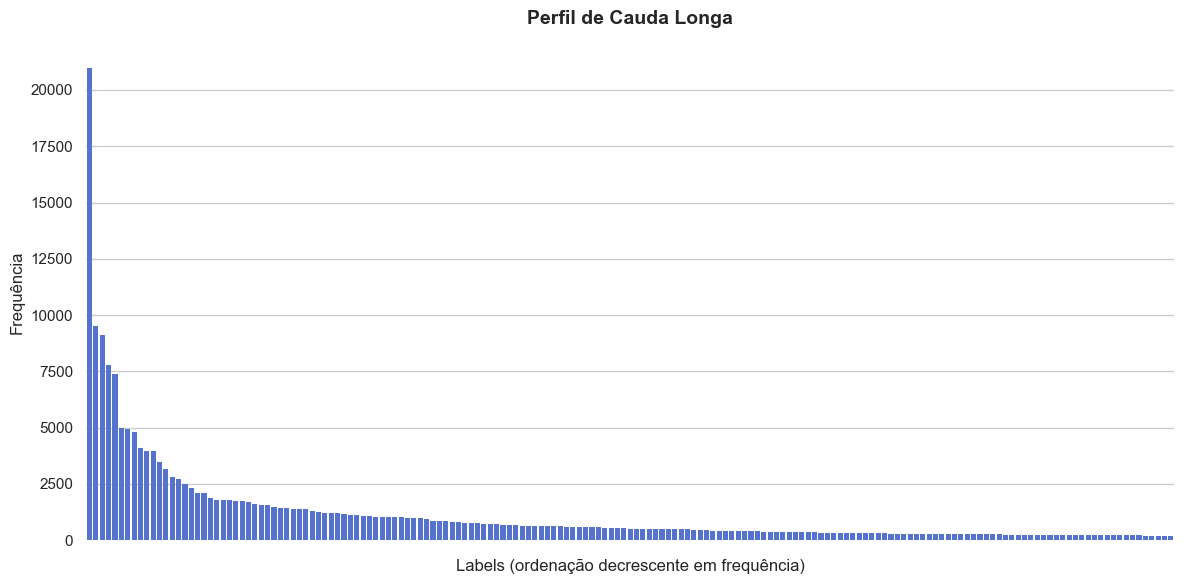

In [17]:
label_counts_sorted = label_counts.sort_values(by="Frequência", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=label_counts_sorted,x=label_counts_sorted.index, y="Frequência",  
    orient="v", color="royalblue", edgecolor="none",)
ax.set_xticklabels([])
ax.set_xlabel("Labels (ordenação decrescente em frequência)", fontsize=12)
ax.set_ylabel("Frequência", fontsize=12)
plt.title("Perfil de Cauda Longa", fontsize=14, pad=15, weight="bold",)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Ao observar a cardinalidade de cada documento, nos deparamos exatamente com o que é relatado na literatura: temos alguns labels muito frequentes, e outros poucos frequentes, configurando classes raras. Precisamos analisar quais são essas classes e qual sua importancia para determinarmos como vamos lidar com elas.

In [20]:
label_counts_all = df_exploded["labels_list"].value_counts()
top_10 = label_counts_all.nlargest(10).index.tolist()
bottom_10 = label_counts_all.nsmallest(10).index.tolist()

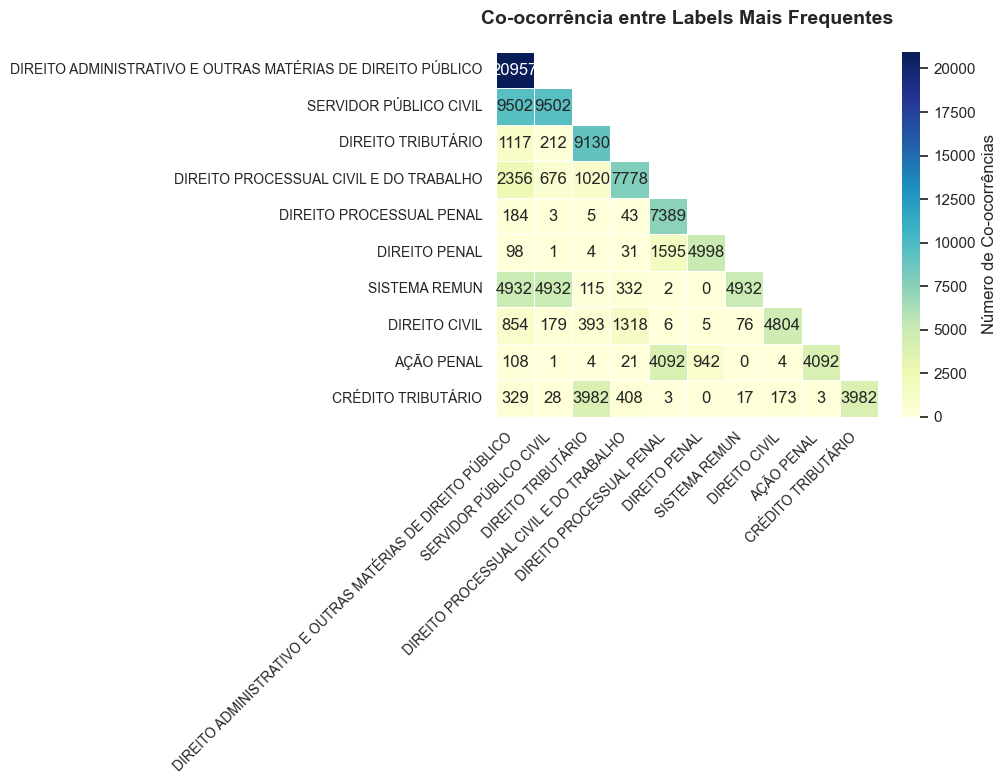

In [18]:

co_matrix = pd.DataFrame(0, index=top_10, columns=top_10_labels, dtype=int)
#preenche a matriz varrendo cada lista de labels do seu df original
for labels_list in df["labels_list"]:
    valid_labels = [label for label in labels_list if label in top_10]
    for i in range(len(valid_labels)):
        for j in range(len(valid_labels)):
            co_matrix.loc[valid_labels[i], valid_labels[j]] += 1


plt.figure(figsize=(10, 8))
sns.set_theme(style="white")
mask = np.triu(np.ones_like(co_matrix, dtype=bool), k=1)
ax = sns.heatmap(co_matrix, mask=mask, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "Número de Co-ocorrências"},)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Co-ocorrência entre Labels Mais Frequentes", fontsize=14, pad=20, weight="bold",)
plt.tight_layout()
plt.show()

Algumas coisas interessantes que podemos observar:
1) olhando o cruzamento de Direito Administrativo com Servidor Público Civil (9502) e com Sistema Remun (4932), o valor é exatamente igual ao total da própria label menor, ou seja, praticamente toda vez que aparece "Sistema Remun" ou "Servidor Público Civil", eles estão obrigatoriamente debaixo do guarda-chuva de "Direito Administrativo".
2) Direito Processual Penal, Direito Penal e Ação Penal funcionam como um bloco isolado: co-ocorrem muito entre si (o bloco verde/azul com números como 4092 e 1595), mas têm quase zero relação outros como Direito Tributário ou Administrativo.

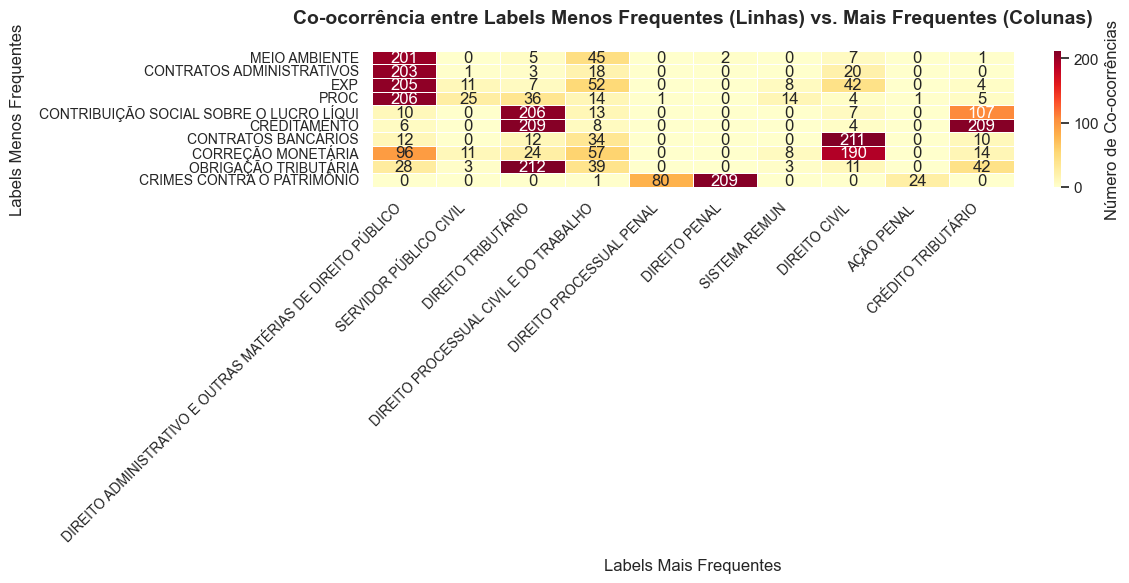

In [21]:
cross_co_matrix = pd.DataFrame(0, index=bottom_10, columns=top_10, dtype=int)
for labels_list in df["labels_list"]:
    current_top = [label for label in labels_list if label in top_10]
    current_bottom = [label for label in labels_list if label in bottom_10]

    for b_label in current_bottom:
        for t_label in current_top:
            cross_co_matrix.loc[b_label, t_label] += 1

plt.figure(figsize=(12, 6))
sns.set_theme(style="white")
ax = sns.heatmap(cross_co_matrix, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Número de Co-ocorrências"},)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title( "Co-ocorrência entre Labels Menos Frequentes (Linhas) vs. Mais Frequentes (Colunas)", fontsize=14, pad=20, weight="bold",)
plt.xlabel("Labels Mais Frequentes", fontsize=12, labelpad=10)
plt.ylabel("Labels Menos Frequentes", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

Deste, podemos destacar:
1) Crimes Contra o Patrimônio tem 209 ocorrências. Dessas, todas as 209 acontecem junto com Direito Penal e 80 junto com Direito Processual Penal. Ela nunca aparece sozinha, ou em outra esfera, como no mundo cível ou tributário.
2) Obrigação Tributária, Creditamento e Contribuição Social têm por volta de 206~212 ocorrências e estão todas concentradas co-ocorrendo na coluna do Direito Tributário e Crédito Tributário.
Isso pode nos indicar algo: essas classes raras não parecem ser como ruído (assuntos muito exóticos), mas sim subclasses extremamente especializadas das labels maiores. Isso nos aponta na direção de modelos hierárquicos: talvez, uma boa estratégia a tentar seja um grande modelo, que divide os textos em grandes labels, as quais são fáceis de diferenciar (como "Penal" e "Tributário"), e depois vários modelos menores, focados em identificar essas subespecialidades.  Outra proposta são modelos ou ensambles do tipo árvore de decisão, que naturalmente têm essa estrutura hierarquica em si. Pode ser que eles se encaixem bem aqui dado a natureza do problema. 

In [22]:
#analisar relacoes com as featurs origem e ministro

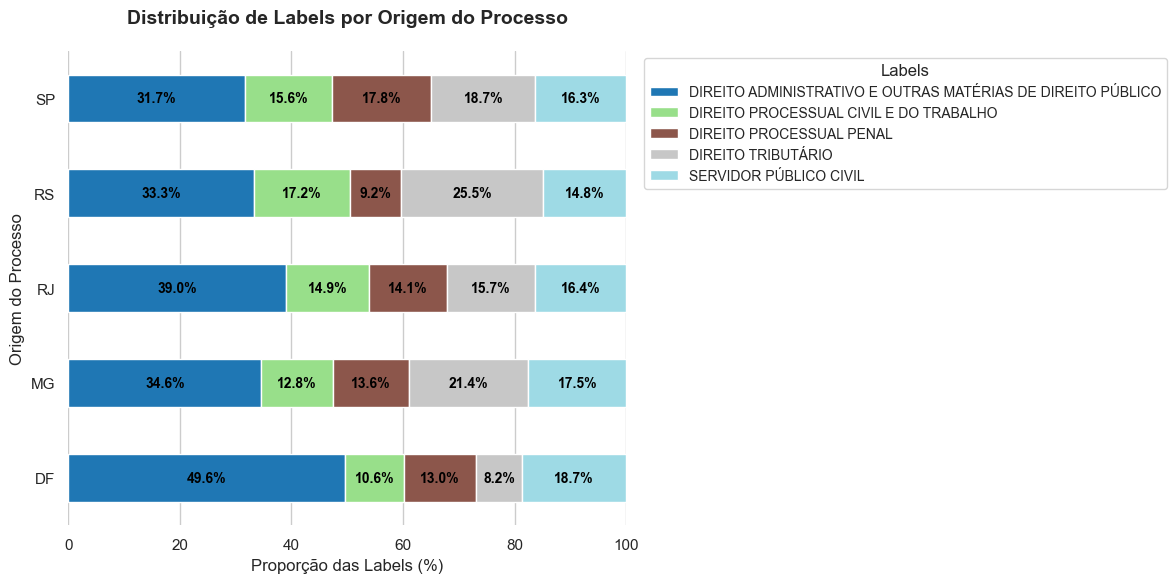

In [27]:
top_origens = df["Origem"].value_counts().nlargest(5).index.tolist()
top_labels = (df_exploded["labels_list"].value_counts().nlargest(5).index.tolist())
df_filtrado = df_exploded[df_exploded["Origem"].isin(top_origens) & df_exploded["labels_list"].isin(top_labels)].copy()
#tab de contingencia
ct = pd.crosstab(df_filtrado["Origem"], df_filtrado["labels_list"])
ct_percentage = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct_percentage.plot(kind="barh", stacked=True, figsize=(12, 6), cmap="tab20")
sns.set_theme(style="whitegrid")
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if width > 2:
        ax.text(x + width / 2, y + height / 2, f"{width:.1f}%", ha="center", va="center", color="black", fontsize=10, weight="bold",)
plt.title("Distribuição de Labels por Origem do Processo", fontsize=14, pad=20, weight="bold",)
plt.xlabel("Proporção das Labels (%)", fontsize=12)
plt.ylabel("Origem do Processo", fontsize=12)
plt.legend(title="Labels", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xlim(0, 100)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Fora a relação (bem esperada) de termos mais processos relacionados a direito público no DF, parece ter uma diferença sim de acordo com a origem, o que é bem triste porque eu queria dropar essa coluna. Talvez possamos substituir ela por uma flag binária tipo "DF ou não", já que a sua distribuição foi a mais diferente, ou fazemos encoding mesmo. Assim, de fato, essa feature não parece fazer toda a diferença do planeta. Mas, haja vista a dificuldade do problema, eu não vou de cara descartá-la pois ela pode ser uma facilitadora pro modelo. Talvez em outro contexto mais simples, eu o fizesse.

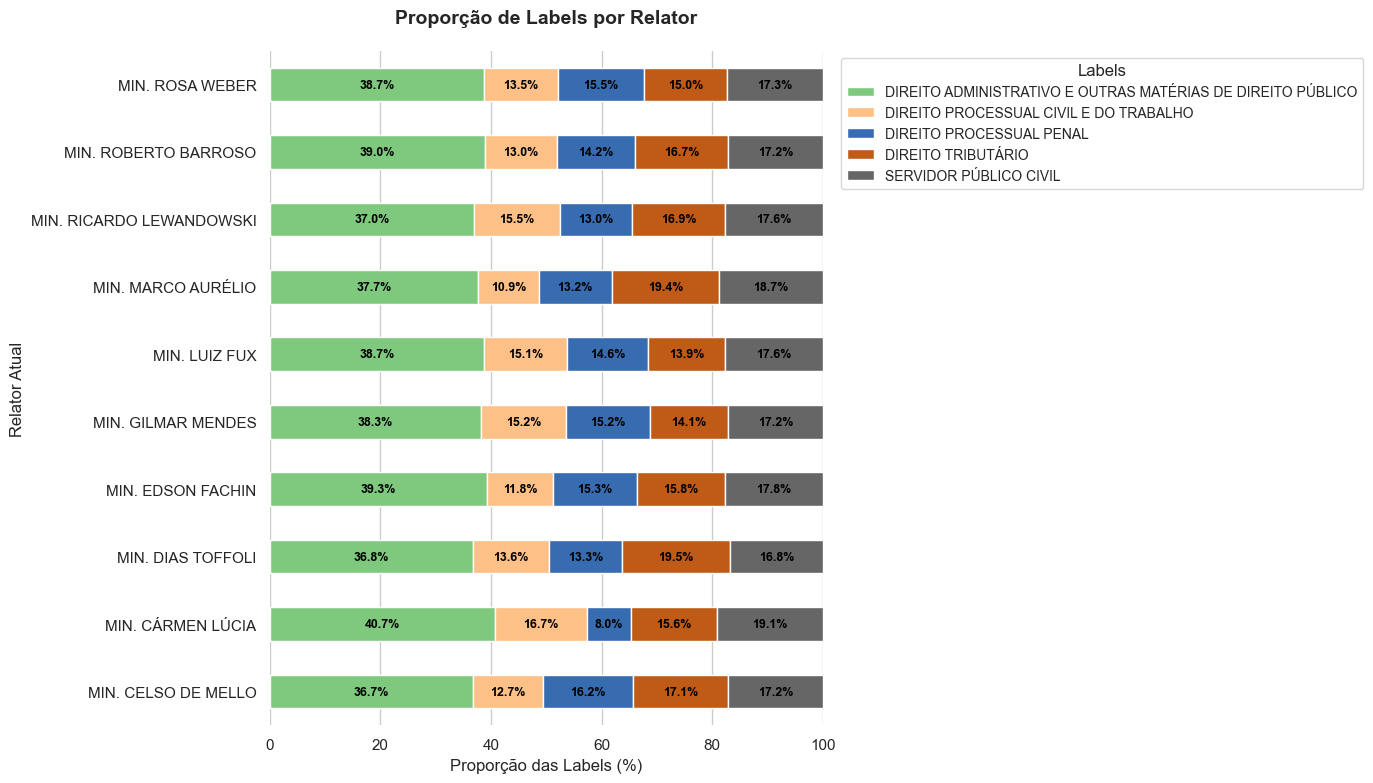

In [28]:
top_relatores = df["Relator_atual"].value_counts().nlargest(10).index.tolist()
top_labels = (df_exploded["labels_list"].value_counts().nlargest(5).index.tolist())
df_filtrado_relator = df_exploded[df_exploded["Relator_atual"].isin(top_relatores) & df_exploded["labels_list"].isin(top_labels)].copy()
ct_relator = pd.crosstab(df_filtrado_relator["Relator_atual"], df_filtrado_relator["labels_list"])
ct_relator_percentage = ct_relator.div(ct_relator.sum(axis=1), axis=0) * 100

sns.set_theme(style="whitegrid")
ax = ct_relator_percentage.plot(kind="barh", stacked=True, figsize=(14, 8), cmap="Accent")

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if width > 2:
        ax.text(x + width / 2, y + height / 2, f"{width:.1f}%", ha="center", va="center", color="black", fontsize=9, weight="bold",)

plt.title("Proporção de Labels por Relator", fontsize=14, pad=20, weight="bold",)
plt.xlabel("Proporção das Labels (%)", fontsize=12)
plt.ylabel("Relator Atual", fontsize=12)
plt.legend(title="Labels", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xlim(0, 100)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Já essa feature parece bem não útil: não vemos diferenças significativas entre os tópicos tratados por cada relator. Não vejo porque manter, então, essa feature, pois não acho que a capacidade preditiva do modelo será aumentada de maneira a justificar o aumento de complexidade da modelagem e o aumento da dimensionalidade do dataset. Na verdade, é possível até que o modelo seja confundido por essa feature, ao tentar encontrar relações onde não há nenhuma significativa. Vou dropar! :)

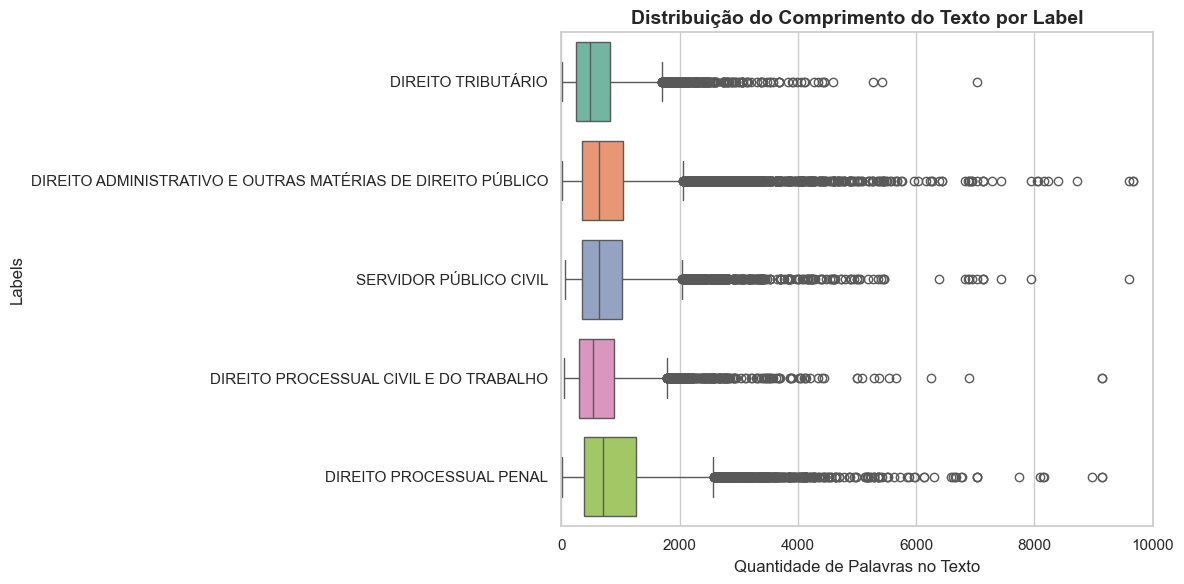

In [24]:
df["qtd_palavras"] = df["texto"].apply(lambda x: len(str(x).split()))
top_5_labels = (df_exploded["labels_list"].value_counts().nlargest(5).index.tolist())
df_top5 = df_exploded[df_exploded["labels_list"].isin(top_5_labels)].copy()
df_top5["qtd_palavras"] = df_top5["texto"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_top5, x="qtd_palavras", y="labels_list", hue="labels_list", palette="Set2", legend=False, )
plt.title( "Distribuição do Comprimento do Texto por Label", fontsize=14, weight="bold",)
plt.xlabel("Quantidade de Palavras no Texto", fontsize=12)
plt.ylabel("Labels", fontsize=12)
#tinha alguns poucos outliers que atrapalhavam a visualização global por isso restringi X aqui
plt.xlim(0, 10000)
plt.tight_layout()
plt.show()

Observamos que a maioria dos nossos textos não são absurdamente longos, o que é bom pois facilita a parte de PLN da tarefa. Além disso, vemos que todas as classes apresentam distribuições relativamente próximas e uma grande quantidade de outliers. Essa feature não parece ser particularmente indicativa de nada. 

<Figure size 1000x500 with 0 Axes>

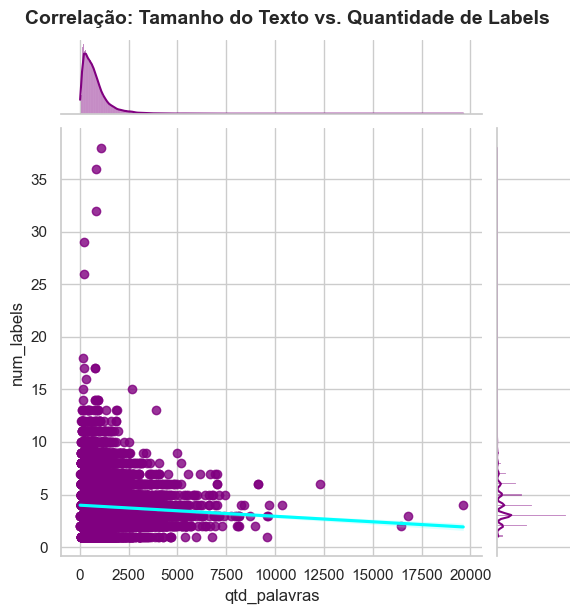

In [25]:
plt.figure(figsize=(10, 5))
sns.regress_plot = sns.jointplot(data=df, x="qtd_palavras", y="num_labels", kind="reg", color="purple", joint_kws={"line_kws": {"color": "cyan"}},)
plt.gcf().suptitle("Correlação: Tamanho do Texto vs. Quantidade de Labels", y=1.02, fontsize=14, weight="bold",)
plt.show()

Podemos ver, de forma sutil e bem dispersa, uma regressão com inclinação negativa. Ou seja, textos maiores não significam mais labels. Ou seja, a quantidade de texto não é indicativo da quantidade de assuntos abordados. Por outro lado, chama a atenção a quantidade de textos pequenos que têm muitos labels, pois isso nos indica que eles podem ser tratados de forma mais superficial/com menos contexto, o que torna mais dificil para o modelo identificar o assunto. Talvez, até, poucas palavras ou termos específicos já sejam justificativa para adição de labels. 

Agora que já temos uma ideia do que vai ficar e sair, vamos arrumar os datasets:

In [37]:
import pyarrow as pa
import pyarrow.parquet as pq
from pyarrow import Table

In [38]:
def ajuste_dataset(path_original, path_final):
    colunas_para_remover = [
        "Processo",
        "Assuntos",
        "Classe_abrev",
        "Data_Autuacao",
        "Data_Decisao",
        "Data_Publicacao",
        "Relator_atual",
        "Partes",
        "Decisao",
        "Legislacao",
        "Observacao_01",
        "Observacao_02",]

    parquet_file = pq.ParquetFile(path_original)
    writer = None
    total_linhas = 0
    for i, batch in enumerate(parquet_file.iter_batches(batch_size=5000)):
        chunk = batch.to_pandas()
        colunas_existentes = [col for col in colunas_para_remover if col in chunk.columns]
        chunk = chunk.drop(columns=colunas_existentes)
        table = Table.from_pandas(chunk, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(path_final, table.schema)
        writer.write_table(table)

    if writer:
        writer.close()

In [39]:
ajuste_dataset(path_original="train.parquet",path_final="trainC.parquet" )
ajuste_dataset(path_original="val.parquet",path_final="valC.parquet")
ajuste_dataset(path_original="test_kaggle.parquet",path_final="testC.parquet")

https://nickcdryan.com/2017/01/23/multi-label-classification-a-guided-tour/

https://www.csie.ntu.edu.tw/~cjlin/libmultilabel/tutorial.html

https://datature.io/blog/introduction-to-multi-label-classification

https://ujangriswanto08.medium.com/what-is-multi-label-classification-understanding-the-basics-06d1ca501123

